# `**ШЕРИНГОВЫЕ УСЛУГИ. Анализ спроса на самокаты.**`

## К нам "обратилась" компания, предоставляющая самокаты в аренду. Она не так давно вышла на рынок, успела накопить некоторые данные по поездкам и теперь желает оптимизировать свой бизнес - перейти на динамический тип ценообразования.

# Задача:проанализировать эффективность текущей деятельности компании,выявить факторы, влияющие на спрос.

# План:
# 0.Предобработка данных
# 1. Проведение расчетов и исследований.
#    1.1 Итоговая стоимость
#    1.2 Таблица почасовый трафик
 #   1.3 Корреляция между параметрами погоды
# 2.Проверка гипотез
# -наши гипотезы
# 3.Регрессивное моделирование
#    3.1 Факторы
#    3.2 Нюансы
# 4.Дашборд и презентация    
# 5. Сдача проекта

#**0.Предобработка. Знакомство с данными**

Два файла: weather.csv и rides.csv

# Weather.csv

In [9]:
import pandas as pd


df = pd.read_csv('weather.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3673 entries, 0 to 3672
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Datetime             3672 non-null   object
 1   Temperature          3618 non-null   object
 2   Precipitation Total  3643 non-null   object
 3   Wind Gust            3673 non-null   object
 4   Wind Speed           3657 non-null   object
 5   Cloud Cover Total    3653 non-null   object
 6   Sunshine Duration    3661 non-null   object
dtypes: object(7)
memory usage: 201.0+ KB


 Пояснение:
 0   Datetime -  время измерения             
 1   Temperature - температура воздуха          
 2   Precipitation Total - осадки  
 3   Wind Gust - скорость ветра            
 4   Wind Speed - порывы ветра (макс скорость)           
 5   Cloud Cover Total - облачность (% покрытия)    
 6   Sunshine Duration - Солнечное сияние (мин)

#Rides.csv

In [12]:
df = pd.read_csv('rides.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Id              102255 non-null  int64  
 1   Start Date      102255 non-null  object 
 2   End Date        102255 non-null  object 
 3   Start Location  102255 non-null  object 
 4   Start District  102255 non-null  object 
 5   End Location    102255 non-null  object 
 6   End District    102255 non-null  object 
 7   Distance        101022 non-null  float64
 8   Promo           102255 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 7.0+ MB


 0   Id - идентификатор поездки              
 1   Start Date - Start Datetime     
 2   End Date - End Datetime        
 3   Start Location - Start Location  
 4   Start District - Start District   
 5   End Location - End Location    
 6   End District - End District    
 7   Distance - Distance        
 8   Promo - применен ли промо-код на бесплатный старт    

# *Предобработаем данные по следующему плану:**

## 1. Наименования столбцов - pep-8
## 2. Тип данных
## 3. Явные дубликаты (До стат. расчетов, чтобы не было смещения!)
## 4. Неявные дубликаты (Категориальные столбцы)
## 5. Аномалии/выбросы
  ## 5.1. Предположить причину возникновения, подумать о необходимости обработки
  ## 5.2. Если обработка нужна, то подход как к пропускам (в следующем пункте)
## 6. Пропуски
  ## 6.1. Стратегий несколько, вопрос в том, как обоснуете свое решение
  ## 6.2. Можно учесть взаимосвязи в данных: погода – соседние по времени наблюдения, поездки
## – время/расстояние/скорость, расстояние между районами
## 7. Аналитический и графический анализ данных + выводы (Сколько и чего имеем по результатам
## обработки)

# **1.Проведение расчетов и исследований.**

- файл 1_week_clean.ipynb

In [18]:
import os
import ast
import pandas as pd
import numpy as np
import seaborn as sns
import re


import matplotlib.pyplot as plt
PATH_OUT = r'D:\code_files\Python\data_analysis_yandex\yandex_final\git\SADTeam\Настя'

Общая информация про файл rides.csv

In [20]:
df = pd.read_csv(PATH_OUT + '\\rides.csv', sep=',', encoding='utf-8', skipinitialspace=True, decimal=',')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Id              102255 non-null  int64 
 1   Start Date      102255 non-null  object
 2   End Date        102255 non-null  object
 3   Start Location  102255 non-null  object
 4   Start District  102255 non-null  object
 5   End Location    102255 non-null  object
 6   End District    102255 non-null  object
 7   Distance        101022 non-null  object
 8   Promo           102255 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 7.0+ MB


### Столбец	Тип признака Описание
#### *Id* - Уникальный идентификатор. Идентификатор поездки, номинативный, может рассматриваться как индекс.
#### *Start Date* - Временной (datetime). Дата и время начала поездки.
#### *End Date* - Временной (datetime). Дата и время окончания поездки.
#### *Start Location* - Категориальный. Название улицы старта.
#### *Start District* - Категориальный. Район отправления.
#### *End Location* - Категориальный. Название улицы прибытия.
#### *End District* - Категориальный. Район прибытия.
#### *Distance* - Количественный (непрерывный). Пройденное расстояние, в метрах.
#### *Promo* - Категориальный (бинарный). Флаг: была ли акция (0/1).

# Очистка DataFrame df, удаляем некорректные строки и преобразуя даты.

## Явные дубликаты

In [24]:
initial_count = len(df)
df = df.drop_duplicates()
final_count = len(df)

removed = initial_count - final_count
print(f"Удалено дубликатов: {removed}")

Удалено дубликатов: 4883


** БУдалено дубликатов: 4883**
** Было: 102255, Стало: 97372**

In [26]:
df.reset_index(drop=True)
df.head(10)

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,Лесная,Юго-Восточный,Западная,Ленинский,4879.0,0
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,Пролетарская,Центральный,Свободы,Ленинский,1846.0,0
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,Комарова,Ленинский,ул. западная,Ленинский,3133.0,0
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,Западная,ленинский,Озерная,Юго-Восточный,3.0,0
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,Свободы,ленинский,ул. чкалова,юго-восточный,5263.0,0


## Неявные дубликаты

In [28]:
print(df['Start Location'].unique(), df['Start District'].unique())

['Шевченко' 'Чехова' 'Буденного' 'Труда' 'Первомайская' 'Лесная'
 'Пролетарская' 'Комарова' 'Западная' 'Свободы' 'Коммунальная' 'Зеленая'
 'Шоссейная' 'Центральная' 'буденного' 'новая' 'Энтузиастов'
 'ул.подгорная' 'Восточная' 'Лермонтова' 'Школьная' 'Пушкина' 'подгорная'
 'рябиновая' 'Солнечная' 'Мичурина' 'ул труда' 'Партизанская' 'Вокзальная'
 'Комсомольская' 'майская' 'Красноармейская' 'Рабочая' 'Почтовая' 'дачная'
 'Заводская' 'Ломоносова' 'карла маркса' 'Советская' 'Красная'
 'Дзержинского' 'Рябиновая' 'ул.советская' 'ул.энергетиков' 'Пионерская'
 'ленина' 'ул. сиреневая' 'гагарина' 'юбилейная' 'Цветочная'
 'ул. набережная' 'Сосновая' 'Спортивная' 'Новая' 'Ленина' 'Полевая'
 'ул. строительная' 'Майская' 'Озерная' 'ул.горького' 'ул. восточная'
 'пионерская' 'Энергетиков' 'ул.озерная' 'южная' 'Некрасова'
 'ул.молодежная' 'ул. пионерская' 'Чкалова' 'Речная' 'Парковая'
 'Карла Маркса' 'строителей' 'Кирова' 'Набережная' 'матросова' 'Садовая'
 'колхозная' 'ул. чкалова' 'комарова' 'Луго

**Замена названий улиц**

In [30]:
df['Start District'] = df['Start District'].apply(lambda x: x.lower().replace(' ', '-'))
df['End District'] = df['End District'].apply(lambda x: x.lower().replace(' ', '-'))

def clean_street(name):
    if isinstance(name, str):
        name = name.lower().replace('ул.', '').replace('ул ', '').strip()
        return name
    return name


df['Start Location'] = df['Start Location'].apply(clean_street)
df['End Location'] = df['End Location'].apply(clean_street)

print(df['Start Location'].unique())
print(df['Start District'].unique())
df.head(10)

['шевченко' 'чехова' 'буденного' 'труда' 'первомайская' 'лесная'
 'пролетарская' 'комарова' 'западная' 'свободы' 'коммунальная' 'зеленая'
 'шоссейная' 'центральная' 'новая' 'энтузиастов' 'подгорная' 'восточная'
 'лермонтова' 'школьная' 'пушкина' 'рябиновая' 'солнечная' 'мичурина'
 'партизанская' 'вокзальная' 'комсомольская' 'майская' 'красноармейская'
 'рабочая' 'почтовая' 'дачная' 'заводская' 'ломоносова' 'карла маркса'
 'советская' 'красная' 'дзержинского' 'энергетиков' 'пионерская' 'ленина'
 'сиреневая' 'гагарина' 'юбилейная' 'цветочная' 'набережная' 'сосновая'
 'спортивная' 'полевая' 'строительная' 'озерная' 'горького' 'южная'
 'некрасова' 'молодежная' 'чкалова' 'речная' 'парковая' 'строителей'
 'кирова' 'матросова' 'садовая' 'колхозная' 'луговая' 'крупской'
 'октябрьская' 'березовая' 'вишневая' 'береговая' 'дружбы' 'калинина'
 'суворова' 'дорожная' 'свердлова' 'куйбышева' 'нагорная' 'космонавтов'
 'северная' 'московская' 'гоголя' 'овражная' 'победы' 'кооперативная'
 'совхозная' 'з

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,лесная,юго-восточный,западная,ленинский,4879.0,0
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,пролетарская,центральный,свободы,ленинский,1846.0,0
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,комарова,ленинский,западная,ленинский,3133.0,0
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,западная,ленинский,озерная,юго-восточный,3.0,0
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,свободы,ленинский,чкалова,юго-восточный,5263.0,0


**Распределение улиц по районам**

In [32]:
grouped_streets_by_district = df.groupby('Start District')['Start Location'].unique().to_frame()
grouped_streets_by_district = pd.DataFrame(grouped_streets_by_district)
grouped_streets_by_district['1'] = grouped_streets_by_district['Start Location'].apply(len)
grouped_streets_by_district.sort_values(by='1', ascending=False)

,Start Location,1
Start District,,
центральный,"[труда, пролетарская, зеленая, энтузиастов, пу...",30
юго-восточный,"[шевченко, лесная, коммунальная, центральная, ...",22
ленинский,"[комарова, западная, свободы, подгорная, лермо...",14
северо-западный,"[первомайская, новая, школьная, рябиновая, раб...",13
заречный,"[чехова, шоссейная, комсомольская, пионерская,...",6
октябрьский,"[буденного, восточная, майская, ломоносова, сп...",6


In [33]:
initial_count = len(df)
df = df.drop_duplicates()
print(f"Удалено неявных дубликатов: {initial_count - len(df)}")

Удалено неявных дубликатов: 0


In [34]:
df.dropna(subset=["Distance"], inplace=True)
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])
df.dropna(subset=['Start Date', 'End Date'], inplace=True)

## Нормализация данных: добавление скорости, продолжительности поездки, сезоны

**Приведение времени к формату datetime, добавление сезонов и промежутка дня*

In [37]:
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])

df['Start Month'] = df['Start Date'].dt.month
df['End Month'] = df['End Date'].dt.month

seasons = {
    12: 'Зима', 1: 'Зима', 2: 'Зима',
    3: 'Весна', 4: 'Весна', 5: 'Весна',
    6: 'Лето', 7: 'Лето', 8: 'Лето',
    9: 'Осень', 10: 'Осень', 11: 'Осень'
}

df['Start Season'] = df['Start Month'].map(seasons)
df['End Season'] = df['End Month'].map(seasons)

def time_day(x):
    if 5 <= x <= 12:
        return 'Утро'
    elif 12 < x <= 18:
        return 'День'
    elif 18 < x <= 22:
        return 'Вечер'
    return 'Ночь'

df['Time of Day'] = df['Start Date'].apply(lambda x: time_day(x.hour))
df.loc[:, 'Start Hour'] = df['Start Date'].dt.hour
df.loc[:, 'Day of Week'] = df['Start Date'].dt.day_name()

#### Добавление длительности поездки, средней скорости

In [39]:
df['Time Start'] = df['Start Date'].dt.time
df['Time End'] = df['End Date'].dt.time

df['Duration'] = (df['End Date'] - df['Start Date']).dt.total_seconds() / 60

df['Distance'] = pd.to_numeric(df['Distance'], errors='coerce')

df['Speed (km/h)'] = (df['Distance'] / 1000) / (df['Duration'] / 60)
df.head(10)

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,End Month,Start Season,End Season,Time of Day,Start Hour,Day of Week,Time Start,Time End,Duration,Speed (km/h)
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:01:03,09:24:45,23.700000,10.301266
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:01:07,09:29:32,28.416667,9.533138
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:04:27,09:42:46,38.316667,7.077860
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:06:34,09:38:23,31.816667,7.318806
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:09:27,09:40:07,30.666667,7.882826
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,лесная,юго-восточный,западная,ленинский,4879.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:10:09,09:49:56,39.783333,7.358358
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,пролетарская,центральный,свободы,ленинский,1846.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:15:12,09:26:01,10.816667,10.239753
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,комарова,ленинский,западная,ленинский,3133.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:19:13,09:40:03,20.833333,9.023040
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,западная,ленинский,озерная,юго-восточный,3.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:21:42,09:39:04,17.366667,0.010365
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,свободы,ленинский,чкалова,юго-восточный,5263.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:28:00,10:02:08,34.133333,9.251367


## Аномалии и выбросы

**Анализ дистанции: строк > 10000 и <=5 около 3363**

**Почему значения Distance < 100 м — это аномалия?**
- Физическая нереалистичность:

Поездка на самокате длиной 3–50 метров — это скорее шаг пешком. Реальный пользователь вряд ли бы взял самокат на такую дистанцию.
Это может быть результатом ошибки GPS, неправильного старта/финиша, тестов, или неудачного трекинга.

- Время поездки несоразмерно маленькой дистанции:

Можно встретить поездку длиной 4 метра, которая длится 10+ минут — это маловероятно и указывает на ошибку в геоданных.

- Повторяющиеся адреса:

Начальная и конечная локация могут совпадать (самокат не двигался), но всё равно расстояние не ноль — ещё один признак сбоя в данных.

In [43]:
q1 = df['Distance'].quantile(0.25)
q2 = df['Distance'].quantile(0.50)  # или median()
q3 = df['Distance'].quantile(0.75)
iqr = q3 - q1

print(f"Q1 (25%): {q1}")
print(f"Q2 (Median): {q2}")
print(f"Q3 (75%): {q3}")
print(f"IQR (Q3 - Q1): {iqr}")

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df['Distance'] < lower_bound) | (df['Distance'] > upper_bound)]
print(f"Количество выбросов по Distance: {len(outliers)}")


Q1 (25%): 3045.0
Q2 (Median): 3703.0
Q3 (75%): 4431.0
IQR (Q3 - Q1): 1386.0
Количество выбросов по Distance: 4676


- Q1 (25%): 3045.0
- Q2 (Median): 3703.0
- Q3 (75%): 4431.0
- IQR (Q3 - Q1): 1386.0
- Количество выбросов по Distance: 4676

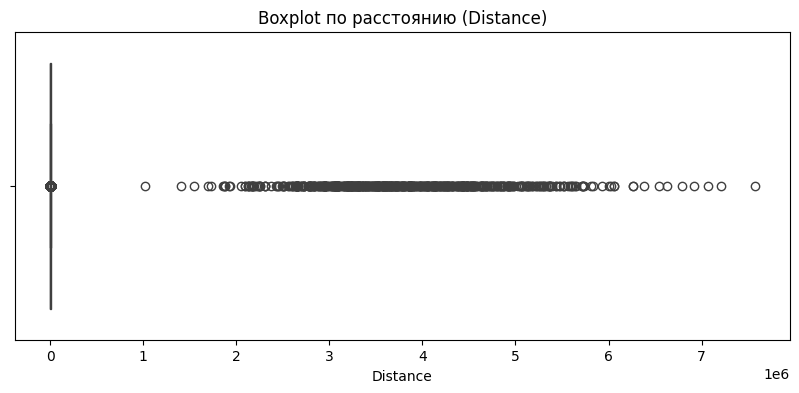

    Start Location  End Location   Distance   Duration
8         западная       озерная        3.0  17.366667
21      лермонтова        дружбы        5.0  29.433333
67          ленина      овражная        5.0  52.216667
70    строительная  строительная        4.0  17.900000
108      заводская     свердлова        4.0  33.466667
128     спортивная       свободы  4416111.0  29.966667
135        полевая    пионерская  6627165.0  49.450000
144      березовая       майская        4.0  37.350000
189        луговая         труда        4.0  42.383333
221   дзержинского     восточная        4.0  23.633333
Количество аномальных строк в Distance: 3514
Количество поездок с дистанцией меньше 100 м: 2923
Количество поездок с дистанцией более 10000 м: 591


In [45]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Distance'])
plt.title("Boxplot по расстоянию (Distance)")
plt.show()

anomalies_distance = df[(df['Distance'] <= 100) | (df['Distance'] > 10000)]
anomalies_count = anomalies_distance.shape[0]
print(anomalies_distance[['Start Location', 'End Location', 'Distance', 'Duration']].head(10))

low_distance_count = df[df['Distance'] < 100].shape[0]
high_distance_count = df[df['Distance'] > 10000].shape[0]

print(f"Количество аномальных строк в Distance: {anomalies_count}")
print(f"Количество поездок с дистанцией меньше 100 м: {low_distance_count}")
print(f"Количество поездок с дистанцией более 10000 м: {high_distance_count}")

Количество выбросов по каждому району:
Start District
центральный        917
юго-восточный      658
северо-западный    594
ленинский          539
октябрьский        479
заречный           338
Name: is_outlier, dtype: int64
Аномальных строк по условию Distance < 100: 2923
Аномальных строк по условию Distance > upper_bound: 607
Выбросы по Distance удалены.


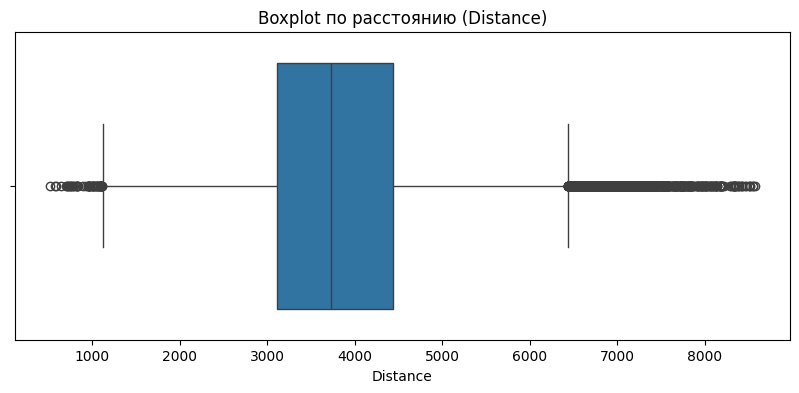

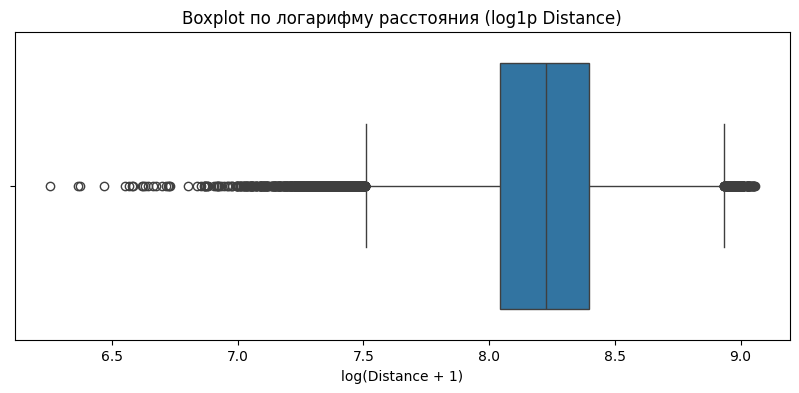

In [46]:
# Квартильные границы
q1 = df['Distance'].quantile(0.25)
q3 = df['Distance'].quantile(0.75)
iqr = q3 - q1

# Границы для определения выбросов
condition = (df['Distance'] < 100) & (df['Duration'] > 8)
upper_bound = q3 + 3 * iqr

df1 = df.copy()
df1['is_outlier'] = (condition) | (df1['Distance'] > upper_bound)
outliers_by_district = df1.groupby('Start District')['is_outlier'].sum()
print("Количество выбросов по каждому району:")
print(outliers_by_district.sort_values(ascending=False))

condition = (df['Distance'] < 100)
condition_large = (df['Distance'] > upper_bound)

print(f"Аномальных строк по условию Distance < 100: {condition.sum()}")
print(f"Аномальных строк по условию Distance > upper_bound: {condition_large.sum()}")

df = df[(df['Distance'] >= 100) & (df['Distance'] <= upper_bound)]

print("Выбросы по Distance удалены.")


plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Distance'])
plt.title("Boxplot по расстоянию (Distance)")
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=np.log1p(df['Distance']))  # log1p = log(1 + x) для работы с нулями
plt.title("Boxplot по логарифму расстояния (log1p Distance)")
plt.xlabel("log(Distance + 1)")
plt.show()


- Удалено аномальных строк по условию Distance < 100: 2923
- Удалено Аномальных строк по условию Distance > upper_bound: 60
#####
Выбросы по Distance удалены.

##### Почему могли возникнуть аномалии и такие выбросы?
##### - GPS плохо работает в центре, поэтому не видно остановку самоката, следовательно время поездки увеличивается, не смотря на стоячее положение
##### - По распределению пропусков видно, что в центре аномалий больше, что также можно приурочить к некорректной работе GPS**

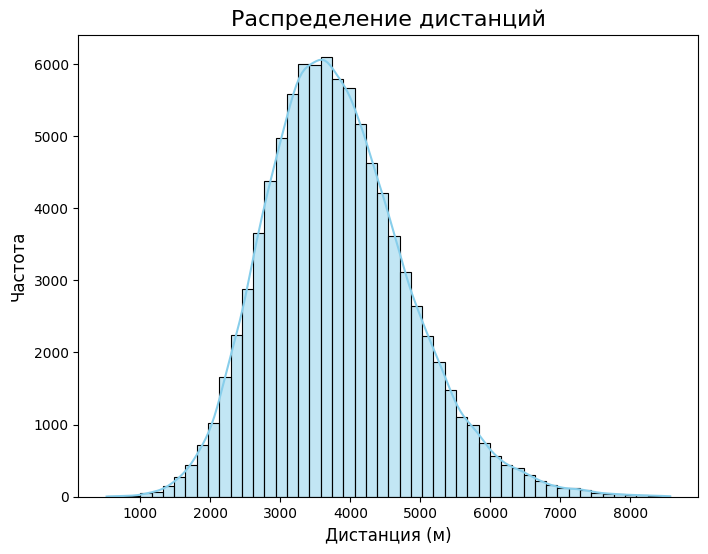

In [49]:
df = df[df['Distance'] <= 10000]
plt.figure(figsize=(8, 6))
sns.histplot(df['Distance'], kde=True, color='skyblue', bins=50)

plt.title('Распределение дистанций', fontsize=16)
plt.xlabel('Дистанция (м)', fontsize=12)
plt.ylabel('Частота', fontsize=12)

plt.show()

In [50]:
missing_end_date = df[df['End Date'].isna()]
print(f"Пропусков в 'End Date': {len(missing_end_date)}")

print(missing_end_date[['Start Date', 'End Date']].head(10))


Пропусков в 'End Date': 0
Empty DataFrame
Columns: [Start Date, End Date]
Index: []


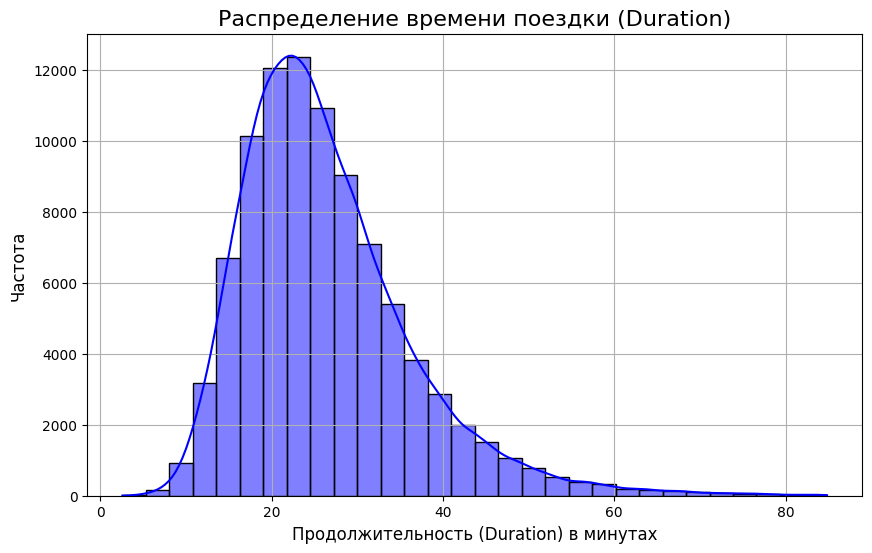

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Построение гистограммы распределения для столбца 'Duration'
plt.figure(figsize=(10, 6))
sns.histplot(df['Duration'], kde=True, bins=30, color='blue')

# Настройки графика
plt.title('Распределение времени поездки (Duration)', fontsize=16)
plt.xlabel('Продолжительность (Duration) в минутах', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid(True)

# Показать график
plt.show()

# Нормализация данных в столбцах DataFrame df

**Добавляем в DataFrame df новые признаки (колонки), которые помогают глубже анализировать данные поездок: когда они происходили, как долго длились, с какой скоростью и в какое время суток.**

In [54]:
df['Start Month'] = df['Start Date'].dt.month
df['End Month'] = df['End Date'].dt.month

seasons = {
    12: 'Зима', 1: 'Зима', 2: 'Зима',
    3: 'Весна', 4: 'Весна', 5: 'Весна',
    6: 'Лето', 7: 'Лето', 8: 'Лето',
    9: 'Осень', 10: 'Осень', 11: 'Осень'
}

df['Start Season'] = df['Start Month'].map(seasons)
df['End Season'] = df['End Month'].map(seasons)

df['Time Start'] = df['Start Date'].dt.time
df['Time End'] = df['End Date'].dt.time

df['Duration'] = (df['End Date'] - df['Start Date']).dt.total_seconds() / 60

df['Distance'] = pd.to_numeric(df['Distance'], errors='coerce')
df['Speed (km/h)'] = (df['Distance'] / 1000) / (df['Duration'] / 60)

def time_day(x):
    if 5 <= x <= 12:
        return 'Утро'
    elif 12 < x <= 18:
        return 'День'
    elif 18 < x <= 22:
        return 'Вечер'
    return 'Ночь'

df['Time of Day'] = df['Start Date'].apply(lambda x: time_day(x.hour))
df.loc[:, 'Start Hour'] = df['Start Date'].dt.hour
df.loc[:, 'Day of Week'] = df['Start Date'].dt.day_name()
df

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,End Month,Start Season,End Season,Time of Day,Start Hour,Day of Week,Time Start,Time End,Duration,Speed (km/h)
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:01:03,09:24:45,23.700000,10.301266
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:01:07,09:29:32,28.416667,9.533138
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:04:27,09:42:46,38.316667,7.077860
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:06:34,09:38:23,31.816667,7.318806
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:09:27,09:40:07,30.666667,7.882826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,озерная,юго-восточный,первомайская,северо-западный,3302.0,0,7,8,Лето,Лето,Ночь,23,Monday,23:45:06,00:06:55,21.816667,9.081131
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,мичурина,ленинский,садовая,заречный,4992.0,0,7,8,Лето,Лето,Ночь,23,Monday,23:46:01,00:25:35,39.566667,7.570008
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,лермонтова,ленинский,куйбышева,центральный,2781.0,0,7,8,Лето,Лето,Ночь,23,Monday,23:48:04,00:09:21,21.283333,7.839937
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,рябиновая,северо-западный,энергетиков,юго-восточный,6466.0,0,7,8,Лето,Лето,Ночь,23,Monday,23:51:41,00:38:04,46.383333,8.364211


**Поиск и удаление дубликатов в DataFrame df, основываясь на дате начала поездки и районе отправления.**

In [56]:
duplicates = df[df.duplicated(subset=['Start Date', 'Start District'], keep=False)]
df = df.drop_duplicates(subset=['Start Date', 'Start District'], keep='first')
df

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,End Month,Start Season,End Season,Time of Day,Start Hour,Day of Week,Time Start,Time End,Duration,Speed (km/h)
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:01:03,09:24:45,23.700000,10.301266
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:01:07,09:29:32,28.416667,9.533138
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:04:27,09:42:46,38.316667,7.077860
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:06:34,09:38:23,31.816667,7.318806
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:09:27,09:40:07,30.666667,7.882826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,озерная,юго-восточный,первомайская,северо-западный,3302.0,0,7,8,Лето,Лето,Ночь,23,Monday,23:45:06,00:06:55,21.816667,9.081131
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,мичурина,ленинский,садовая,заречный,4992.0,0,7,8,Лето,Лето,Ночь,23,Monday,23:46:01,00:25:35,39.566667,7.570008
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,лермонтова,ленинский,куйбышева,центральный,2781.0,0,7,8,Лето,Лето,Ночь,23,Monday,23:48:04,00:09:21,21.283333,7.839937
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,рябиновая,северо-западный,энергетиков,юго-восточный,6466.0,0,7,8,Лето,Лето,Ночь,23,Monday,23:51:41,00:38:04,46.383333,8.364211


# Анализ факторов, влияющих на спрос, и визуализирует результаты. Он показывает когда (по сезонам, дням, часам) чаще всего происходят поездки, а также среднюю длительность поездок в зависимости от времени года

Start Season
Весна    26.393389
Лето     26.363113
Name: Duration, dtype: float64
Day of Week
Sunday       17131
Saturday     16981
Friday       13314
Monday       12035
Wednesday    11030
Thursday     10899
Tuesday      10567
Name: count, dtype: int64
Start Hour
0     1102
1      534
2      413
3      178
4      204
5      789
6     2322
7     3314
8     3757
9     3618
10    3504
11    3063
12    3433
13    3949
14    5000
15    5782
16    6693
17    7337
18    7748
19    8203
20    7705
21    5988
22    4565
23    2756
Name: count, dtype: int64


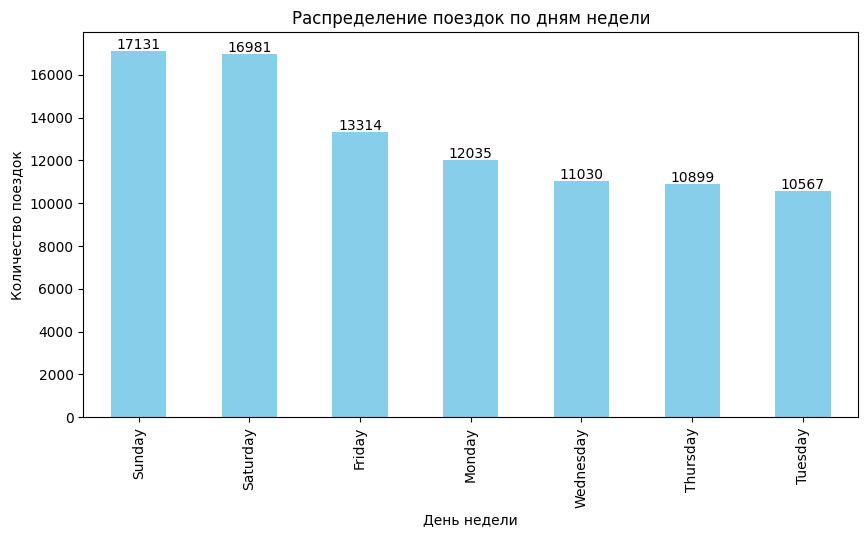

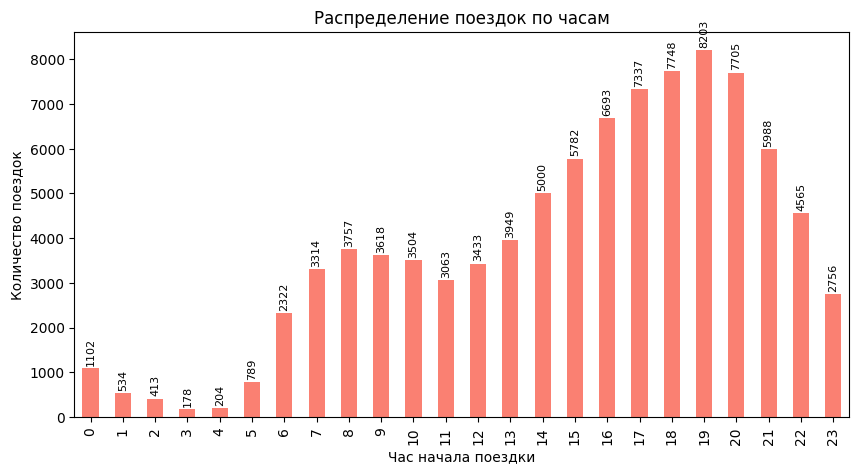

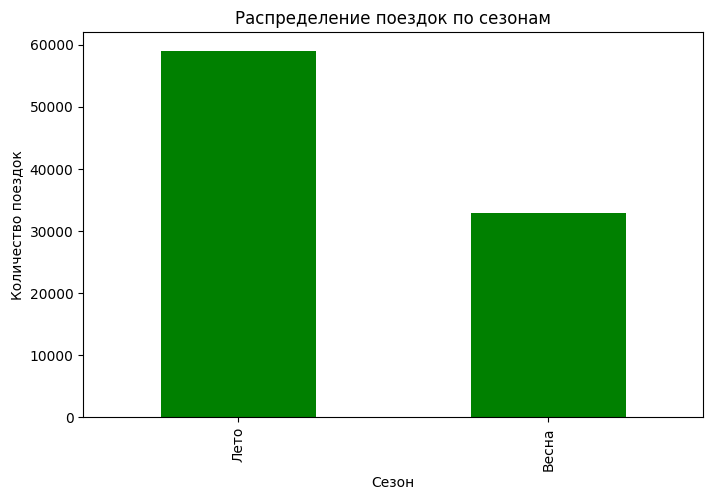

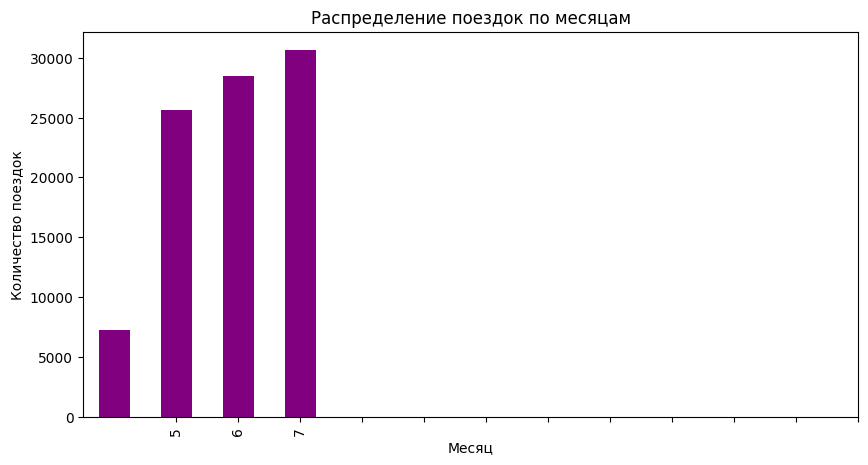

In [58]:
# Анализ факторов, влияющих на спрос
# 1. Средняя длительность поездки по сезонам
season_duration = df.groupby('Start Season')['Duration'].mean()
print(season_duration)

# 2. Количество поездок по дням недели
day_counts = df['Day of Week'].value_counts()
print(day_counts)

# 3. Количество поездок по часам
hour_counts = df['Start Hour'].value_counts().sort_index()
print(hour_counts)

# 4. Количество поездок по сезонам
season_counts = df['Start Season'].value_counts()

# 5. Количество поездок по месяцам
month_counts = df['Start Month'].value_counts().sort_index()

# Визуализация данных с аннотациями
plt.figure(figsize=(10, 5))
day_counts.plot(kind='bar', color='skyblue')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по дням недели')
for i, v in enumerate(day_counts):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)
plt.show()

plt.figure(figsize=(10, 5))
hour_counts.plot(kind='bar', color='salmon')
plt.xlabel('Час начала поездки')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по часам')
for i, v in enumerate(hour_counts):
    plt.text(i, v + 100, str(v), ha='center', fontsize=8, rotation=90)
plt.show()

plt.figure(figsize=(8, 5))
season_counts.plot(kind='bar', color='green')
plt.xlabel('Сезон')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по сезонам')
plt.show()

plt.figure(figsize=(10, 5))
month_counts.plot(kind='bar', color='purple')
plt.xlabel('Месяц')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по месяцам')
plt.xticks(range(1, 13))
plt.show()




#### Нулевая гипотеза: День недели влияет на количество поездок: в выходные поездок больше

Day of Week
Sunday       17131
Saturday     16981
Friday       13314
Monday       12035
Wednesday    11030
Thursday     10899
Tuesday      10567
Name: count, dtype: int64


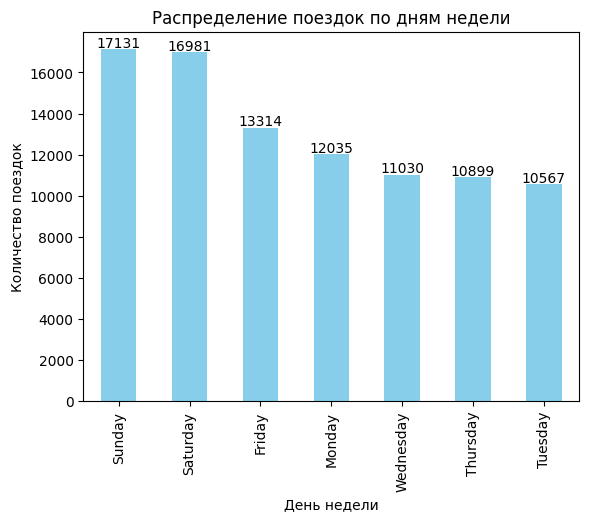

In [60]:
# 2. Количество поездок по дням недели
day_counts = df['Day of Week'].value_counts()
print(day_counts)
day_counts.plot(kind='bar', color='skyblue')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по дням недели')
for i, v in enumerate(day_counts):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)
plt.show()

**Анализ распределения поездок по районам в будние и выходные дни.**

In [71]:
df.loc[:, 'Weekday'] = df['Start Date'].dt.weekday
df.loc[:, 'Day Type'] = df['Weekday'].apply(lambda x: 'Будний день' if x < 5 else 'Выходной')

district_day_type_distribution = (
    df.groupby(['Day Type', 'Start District'])
       .size()
       .reset_index(name='Количество поездок')
)

day_type_order = ['Будний день', 'Выходной']
district_day_type_distribution['Day Type'] = pd.Categorical(
    district_day_type_distribution['Day Type'],
    categories=day_type_order,
    ordered=True
)

district_day_type_distribution = (
    district_day_type_distribution
    .sort_values(by=['Day Type', 'Количество поездок'], ascending=[True, False])
    .reset_index(drop=True)
)
print(district_day_type_distribution)

       Day Type   Start District  Количество поездок
0   Будний день      центральный               15521
1   Будний день    юго-восточный               10914
2   Будний день        ленинский                9150
3   Будний день  северо-западный                9078
4   Будний день      октябрьский                7785
5   Будний день         заречный                5397
6      Выходной      центральный                8120
7      Выходной    юго-восточный                6555
8      Выходной        ленинский                5579
9      Выходной  северо-западный                5546
10     Выходной      октябрьский                4883
11     Выходной         заречный                3429


In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Start District', y='Количество поездок', hue='Day Type', data=district_day_type_distribution)

plt.title('Распределение количества поездок по районам (будний день vs выходной)', fontsize=16)
plt.xlabel('Район', fontsize=14)
plt.ylabel('Количество поездок', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Тип дня')

plt.tight_layout()
plt.show()

#### Итог: Нулевая гипотеза подтверждена
#### День недели кардинально влияет на распределение поездок, в выходные дни и пятницу поездок наблюдается значительно больше

#### Нулевая гипотеза: В будние дни средняя скорость выше
#### Построение графика распределения поездок по дням недели со скоростью по каждому дню

In [ ]:
speed_by_weekday = df.groupby('Weekday')['Speed (km/h)'].agg(['mean', 'count']).reset_index()

# Получаем имена дней недели для отображения на графике
weekday_names = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
speed_by_weekday['Weekday Name'] = speed_by_weekday['Weekday'].map(lambda x: weekday_names[x])

# Сортируем по дню недели для корректного отображения
speed_by_weekday = speed_by_weekday.sort_values(by='Weekday')

fig, ax1 = plt.subplots(figsize=(10, 6))

# График количества поездок
ax1.bar(speed_by_weekday['Weekday Name'], speed_by_weekday['count'], color='lightblue', label='Количество поездок')
ax1.set_xlabel('День недели')
ax1.set_ylabel('Количество поездок')
ax1.set_title('Распределение поездок по дням недели')

# Добавим второй график для средней скорости
ax2 = ax1.twinx()
ax2.plot(speed_by_weekday['Weekday Name'], speed_by_weekday['mean'], color='orange', marker='o', label='Средняя скорость (км/ч)', linewidth=2)
ax2.set_ylabel('Средняя скорость (км/ч)', color='orange')

# Показать легенду
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Показать график
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Итог: Нулевая гипотеза подтверждается.
#### В будние дни средняя скорость значительно больше. Предположение: В субботу и воскресенье пользователи предпочитают кататься по паркам, где есть ограничение по скорости + некуда торопиться, поездка превращается в прогулочную

**Строим гистограмму распределения дистанций поездок**

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Distance'], kde=True, color='skyblue', bins=50)

# Добавим подписи и заголовок
plt.title('Распределение дистанций', fontsize=16)
plt.xlabel('Дистанция (м)', fontsize=12)
plt.ylabel('Частота', fontsize=12)

# Показать график
plt.show()

# Рассчитываем стоимость каждой поездки на основе времени суток и дня недели, применяя динамическую тарифную сетку.

In [75]:
def get_rate(weekday, hour):
    if weekday < 5:  # Пн–Пт
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 5
        elif 16 <= hour < 22:
            return 6
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 5
    else:  # Сб–Вс
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 6
        elif 16 <= hour < 22:
            return 7
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 6


df['Weekday'] = df['Start Date'].dt.weekday
df['Start Hour'] = df['Start Date'].dt.hour

df['Rate per Minute'] = df.apply(lambda row: get_rate(row['Weekday'], row['Start Hour']), axis=1)

df['Trip Cost'] = df['Duration'] * df['Rate per Minute']
df

C:\Temp\ipykernel_11728\1598019194.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Weekday'] = df['Start Date'].dt.weekday
C:\Temp\ipykernel_11728\1598019194.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Start Hour'] = df['Start Date'].dt.hour
C:\Temp\ipykernel_11728\1598019194.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyda

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,...,Start Hour,Day of Week,Time Start,Time End,Duration,Speed (km/h),Weekday,Day Type,Rate per Minute,Trip Cost
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0,4,...,9,Saturday,09:01:03,09:24:45,23.700000,10.301266,5,Выходной,4,94.800000
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0,4,...,9,Saturday,09:01:07,09:29:32,28.416667,9.533138,5,Выходной,4,113.666667
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0,4,...,9,Saturday,09:04:27,09:42:46,38.316667,7.077860,5,Выходной,4,153.266667
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0,4,...,9,Saturday,09:06:34,09:38:23,31.816667,7.318806,5,Выходной,4,127.266667
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0,4,...,9,Saturday,09:09:27,09:40:07,30.666667,7.882826,5,Выходной,4,122.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,озерная,юго-восточный,первомайская,северо-западный,3302.0,0,7,...,23,Monday,23:45:06,00:06:55,21.816667,9.081131,0,Будний день,5,109.083333
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,мичурина,ленинский,садовая,заречный,4992.0,0,7,...,23,Monday,23:46:01,00:25:35,39.566667,7.570008,0,Будний день,5,197.833333
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,лермонтова,ленинский,куйбышева,центральный,2781.0,0,7,...,23,Monday,23:48:04,00:09:21,21.283333,7.839937,0,Будний день,5,106.416667
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,рябиновая,северо-западный,энергетиков,юго-восточный,6466.0,0,7,...,23,Monday,23:51:41,00:38:04,46.383333,8.364211,0,Будний день,5,231.916667


**Столбчатая диаграмму (bar plot), показывающую распределение поездок по времени суток (Утро, День, Вечер, Ночь)**

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Time of Day', data=df, palette='Set2')

plt.title('Распределение категориальных признаков', fontsize=16)
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Частота', fontsize=12)

plt.show()

**Два анализа: один — визуализирует распределение стоимости поездки по районам, а второй — рассчитывает среднюю продолжительность поездки по районам.**

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Start District', y='Trip Cost', data=df)

plt.xticks(rotation=45, ha='right')
plt.xlabel('Район')
plt.ylabel('Стоимость поездки')
plt.title('Распределение стоимости поездок по районам')

plt.show()

average_duration_by_district = df.groupby('Start District')['Duration'].mean().sort_values(ascending=False)
print(average_duration_by_district)

In [ ]:
district_price = df.groupby('Start District')['Trip Cost'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
district_price.plot(kind='bar', color='lightgreen')
plt.xlabel('Район')
plt.ylabel('Средняя цена (руб.)')
plt.title('Распределение средней цены по районам')
plt.xticks(rotation=45, ha='right')
plt.show()

**Выведем несколько значений.
Среднее значение стоимости поездки:
Максимальное значение стоимости поездки:
Медиану стоимости поездки:**


In [ ]:
print(df['Trip Cost'].mean())
print(df['Trip Cost'].max())
print(df['Trip Cost'].median())

График для отображения средней продолжительности поездки по различным районам, чтобы наглядно сравнить, где поездки в среднем длительнее, а где короче.

In [ ]:
district_durations = df.groupby("Start District")["Duration"].mean().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=district_durations.values, y=district_durations.index, palette="coolwarm")
plt.xlabel("Средняя продолжительность поездки (мин)")
plt.ylabel("Район старта")
plt.title("Средняя продолжительность поездки по районам")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

** Тепловая карта для визуализации распределения количества поездок по часам дня и районам старта.
- Группировка данных по району старта и часу:
- Сортировка районов по убыванию количества поездок:
- Создание сводной таблицы (pivot table):
- Сортировка таблицы по убыванию количества поездок в районах:
- Построение тепловой карты (Heatmap):
- Настройки графика: **

In [ ]:
grouped = df.groupby(['Start District', 'Start Hour']).size().reset_index(name='Trip Count')
district_order = df['Start District'].value_counts().index.tolist()
pivot_table = grouped.pivot(index='Start District', columns='Start Hour', values='Trip Count').fillna(0)

pivot_table = pivot_table.reindex(district_order)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_table, cmap="YlGnBu", annot=True, fmt=".0f", linewidths=.5)
plt.title("Распределение количества поездок по часу и району старта", fontsize=14)
plt.xlabel("Час дня")
plt.ylabel("Район старта (по убыванию количества поездок)")
plt.tight_layout()
plt.show()

**Два графика: boxplot (ящик с усами) и histplot (гистограмма) для колонки Distance (расстояние). Графики отображаются на одном холсте с использованием подграфиков (subplots).**

In [ ]:
street_distribution = df.groupby(['Start District', 'Start Location']).size().reset_index(name='Поездок')

street_distribution = street_distribution.sort_values(['Start District', 'Поездок'], ascending=[True, False])
g = sns.FacetGrid(
    street_distribution.groupby('Start District').head(8),  # Топ улиц на район
    col='Start District', col_wrap=2, height=4, sharex=False
)
g.map_dataframe(sns.barplot, x='Поездок', y='Start Location', palette='magma')
g.set_titles(col_template="{col_name} район")
g.set_axis_labels("Количество поездок", "Улица")
plt.tight_layout()
plt.show()

**Гистограммы (barplot) для визуализации распределения количества поездок по улицам в разных районах, используя библиотеку Seaborn и FacetGrid для создания нескольких подграфиков (facet plots).**

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot (вертикальный)
sns.boxplot(y=df['Distance'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot of Distance')

# Histplot
sns.histplot(df['Distance'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Histogram of Distance')

plt.tight_layout()
plt.show()

# 1.Итоговая стоимость

In [ ]:

# 1. Кол-во поездок по дням с промо и без
daily_demand = df.groupby(['Date', 'Promo'])['Id'].count().reset_index()
daily_demand.columns = ['Date', 'Promo', 'Trip Count']

# 2. Общая выручка
revenue_summary = df.groupby('Promo')['Trip Cost'].sum().rename(index={0: 'Без промо', 1: 'С промо'})

# 3. Издержки на акцию
# Предположим, скидка 20 рублей на каждую поездку с промо
promo_cost_per_ride = 20
promo_ride_count = df[df['Promo'] == 1].shape[0]
total_promo_cost = promo_cost_per_ride * promo_ride_count

# 4. Чистая прибыль
net_profit = {
    'Без промо': revenue_summary['Без промо'],
    'С промо (чистая)': revenue_summary['С промо'] - total_promo_cost
}

In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=daily_demand, x='Date', y='Trip Count', hue='Promo', palette='Set1')
plt.title('Спрос (кол-во поездок по дням): с промо vs без промо')
plt.ylabel('Число поездок')
plt.xlabel('Дата')
plt.legend(title='Промо', labels=['Без промо', 'С промо'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Среднее количество поездок по часам
heatmap_data = df.groupby(['Start Hour', 'Promo'])['Id'].count().unstack()

plt.figure(figsize=(10, 5))
heatmap_data.plot(kind='bar', stacked=False, colormap='coolwarm')
plt.title('Сравнение поездок по часам: с промо vs без промо')
plt.xlabel('Час старта')
plt.ylabel('Количество поездок')
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# 1. Промо и контрольные периоды
promo_period = (
    (df['Promo'] == 1) &
    (df['Weekday'] == 0) & 
    (df['Start Hour'].between(6, 10))
)

control_period = (
    (df['Promo'] == 0) &
    (df['Start Hour'].between(6, 10)) &
    (df['Weekday'].isin([0, 1, 2, 3, 4, 5, 6]))
)

df_promo = df[promo_period]
df_control = df[control_period]

In [ ]:
# 2. Количество поездок
promo_rides = df_promo.shape[0]
avg_control_rides = df_control.groupby('Weekday')['Id'].count().mean()

print(f"Поездки в промо-период (Пн 6:00–10:00): {promo_rides}")
print(f"Среднее число поездок без промо (в другие дни 6:00–10:00): {avg_control_rides:.1f}")

In [ ]:
avg_cost_promo = df_promo['Trip Cost'].mean()
avg_cost_nonpromo = df_nonpromo['Trip Cost'].mean()

print(f"Средняя выручка за поездку с промо: {avg_cost_promo:.2f} руб.")
print(f"Средняя выручка за поездку без промо: {avg_cost_nonpromo:.2f} руб.")

In [ ]:
# 3. Выручка и потери
mean_trip_cost_no_promo = df_control['Trip Cost'].mean()
expected_revenue = promo_rides * mean_trip_cost_no_promo
actual_revenue = df_promo['Trip Cost'].sum()
promo_loss = expected_revenue - actual_revenue

print(f"\nПотенциальная выручка без промо: {expected_revenue:.2f} ₽")
print(f"Фактическая выручка с промо: {actual_revenue:.2f} ₽")
print(f"Упущенная выручка (стоимость акции): {promo_loss:.2f} ₽")

In [ ]:
growth = promo_rides - avg_control_rides
revenue_from_growth = growth * mean_trip_cost_no_promo

print(f"\nДополнительные поездки в промо: {growth:.1f}")
print(f"Доход от прироста: {revenue_from_growth:.2f} ₽")

if revenue_from_growth > promo_loss:
    print("Акция окупается!")
else:
    print("Акция не окупается.")

In [ ]:
rides_by_day = (
    df[df['Start Hour'].between(6, 9)]
    .groupby(['Weekday', 'Promo'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: 'Без промо', 1: 'С промо'})
)

rides_by_day.index = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

rides_by_day.plot(kind='bar', figsize=(10, 5), title='Число поездок 6:00–10:00 по дням недели')
plt.ylabel("Число поездок")
plt.xlabel("День недели")
plt.grid(axis='y'
plt.tight_layout()
plt.show()

In [ ]:
# Фильтрация поездок с 6 до 9:59
morning_mask = df['Start Hour'].between(6, 9)

# Разделение на понедельники (день акции) и остальные дни
promo_day = df[(df['Weekday'] == 0) & morning_mask]
other_days = df[(df['Weekday'] != 0) & morning_mask]

# Группируем по дате и считаем поездки
promo_day_counts = promo_day.groupby('Date')['Id'].count().rename('Понедельник')
other_day_counts = other_days.groupby('Date')['Id'].count().rename('Остальные дни')

# Соединяем в один датафрейм для сравнения
comparison_df = pd.concat([promo_day_counts, other_day_counts], axis=1)

# Убираем NaN, заменим на 0, если в какой-то дате нет поездок
comparison_df = comparison_df.fillna(0)

# Добавим флаг, что это понедельник или нет
comparison_df['День акции'] = comparison_df['Понедельник'] > 0

# Среднее по группам
avg_promo = comparison_df[comparison_df['День акции']]['Понедельник'].mean()
avg_other = comparison_df[~comparison_df['День акции']]['Остальные дни'].mean()

print(f"Среднее число поездок в Пн (акция): {avg_promo:.1f}")
print(f"Среднее число поездок в другие дни: {avg_other:.1f}")

# Визуализация
plt.figure(figsize=(16, 6))  # было 10x5, стало 16x6
comparison_df[['Понедельник', 'Остальные дни']].plot(
    kind='bar', stacked=False, width=0.8, figsize=(16, 6), color=['#1f77b4', '#ff7f0e']
)
plt.title("Сравнение поездок с 6:00 до 10:00\nПонедельники (акция) vs Остальные дни", fontsize=14)
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Количество поездок", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Рассчитываем прибыль от промокодов и стоимость поездки
df['Profit'] = df['Promo'] * (df['Rate per Minute'] * df['Duration'])  # Прибыль от промокода

# Группируем по району и считаем издержки и прибыль
profit_by_district = df.groupby('Start District').agg({
    'Trip Cost': 'sum',  # Сумма издержек
    'Profit': 'sum'  # Сумма прибыли от промокодов
}).reset_index()

# Добавляем столбец с окупаемостью
profit_by_district['Окупаемость'] = profit_by_district['Profit'] / profit_by_district['Trip Cost']

# Сортируем по окупаемости (по убыванию)
profit_by_district = profit_by_district.sort_values(by='Окупаемость', ascending=False)

# Выводим результат
print(profit_by_district)

# График окупаемости по районам
plt.figure(figsize=(14, 6))
sns.barplot(x='Start District', y='Окупаемость', data=profit_by_district, palette='viridis')
plt.title('Окупаемость акции по районам', fontsize=16)
plt.xlabel('Район', fontsize=12)
plt.ylabel('Окупаемость', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Районы с высокой окупаемостью: Если в некоторых районах наблюдается высокая окупаемость, это может означать, что в этих районах бесплатный старт имеет значительное влияние на прибыль, возможно, из-за высокого спроса или большего числа поездок с промокодами. Это также может свидетельствовать о том, что издержки на поездки в этих районах не столь велики, и акция действительно выгодна для бизнеса.

Районы с низкой окупаемостью: В районах с низкой окупаемостью можно сделать вывод, что либо бесплатный старт не привлекает достаточное количество клиентов, либо стоимость издержек на поездки (даже с бесплатным стартом) слишком велика для того, чтобы акция была прибыльной. Возможно, в этих районах нужно пересмотреть стратегию применения промокодов или даже исключить эту акцию.

Различия в окупаемости между районами могут указывать на важность географического положения для эффективного использования промокодов. Например, если акция работает хуже в более отдаленных или менее развитых районах, это может быть связано с меньшим спросом на поездки или меньшей плотностью поездок в этих районах.

Также стоит учесть возможность, что в некоторых районах с низким доходом людей акции с бесплатным стартом не приводят к увеличению заказов, так как спрос может быть ограничен.

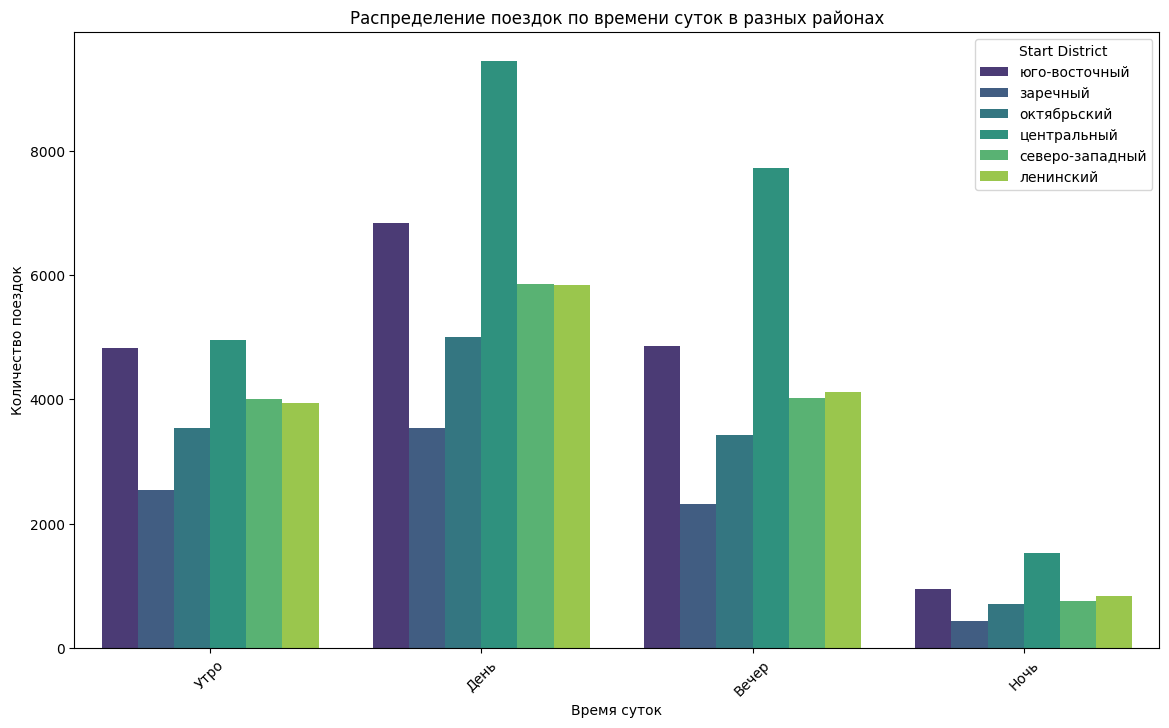

In [284]:
plt.figure(figsize=(14, 8))

# Используем seaborn для построения графика
sns.countplot(data=df, x='Time of Day', hue='Start District', palette='viridis')

# Устанавливаем заголовки и подписи
plt.title('Распределение поездок по времени суток в разных районах')
plt.xlabel('Время суток')
plt.ylabel('Количество поездок')

# Поворот подписей на оси X для удобства
plt.xticks(rotation=45)

# Показываем график
plt.show()

In [88]:
df = df.copy()
df.loc[:, 'Weekday'] = df['Start Date'].dt.weekday

In [90]:
def is_promo_trip(row):
    return (
        row['Promo'] == 1 and
        row['Weekday'] < 5 and
        6 <= row['Start Hour'] < 10
    )

df['Promo Window'] = df.apply(is_promo_trip, axis=1)


In [96]:
# Фильтруем только будние дни, 6–10 утра
mask = (df['Weekday'] < 5) & (df['Start Hour'] >= 6) & (df['Start Hour'] < 10)
morning_df = df[mask]

# Группировка по дате и промо
morning_demand = morning_df.groupby(['Start Date'].dt.date, 'Promo')['Id'].count().unstack(fill_value=0)
morning_demand.columns = ['Без промо', 'С промо']

AttributeError: 'list' object has no attribute 'dt'

In [98]:
mean_without_promo = morning_demand['Без промо'].mean()
mean_with_promo = morning_demand['С промо'].mean()


NameError: name 'morning_demand' is not defined

In [73]:
# Стоимость старта
start_cost = 30

# Добавляем стоимость старта для поездок с промо
df['Adjusted Trip Cost'] = df.apply(lambda row: row['Trip Cost'] - start_cost if row['Promo'] == 1 else row['Trip Cost'], axis=1)

# Разделим на поездки с и без промо
promo_trips = df[df['Promo'] == 1]
non_promo_trips = df[df['Promo'] == 0]

# Рассчитаем общие доходы и затраты
total_income_with_promo = promo_trips['Adjusted Trip Cost'].sum()
total_income_without_promo = non_promo_trips['Trip Cost'].sum()

# Затраты на проведение акции: считаем количество поездок с промо и умножаем на стоимость старта
promo_cost = promo_trips.shape[0] * start_cost

# Печатаем результаты
print(f"Общий доход от поездок с промо: {total_income_with_promo:.2f} рублей")
print(f"Общий доход от поездок без промо: {total_income_without_promo:.2f} рублей")
print(f"Затраты на проведение акции (стоимость старта): {promo_cost:.2f} рублей")

# Окупаемость акции
profit_or_loss = total_income_with_promo + total_income_without_promo - promo_cost
if profit_or_loss >= 0:
    print(f"Акция окупается. Прибыль: {profit_or_loss:.2f} рублей")
else:
    print(f"Акция не окупается. Убыток: {profit_or_loss:.2f} рублей")


KeyError: 'Trip Cost'

In [154]:
df['Date'] = pd.to_datetime(df['Start Date']).dt.date

# Группировка по дате и промо
daily_summary = df.groupby(['Date', 'Promo']).agg({
    'Id': 'count',
    'Distance': 'mean',
    'Duration': 'mean',
    'Speed (km/h)': 'mean'
}).rename(columns={'Id': 'Trip Count'}).reset_index()

# Отдельные выборки
promo_days = daily_summary[daily_summary['Promo'] == 1]
non_promo_days = daily_summary[daily_summary['Promo'] == 0]

C:\Temp\ipykernel_22016\105547539.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Start Date']).dt.date


In [18]:
# Преобразуем дату и создадим колонку только с датой
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['Date'] = df['Start Date'].dt.date

# Количество отъездов из каждой точки по датам
out_df = df.groupby(['Date', 'Start Location']).size().reset_index(name='outflow')

# Количество приездов в каждую точку по датам
in_df = df.groupby(['Date', 'End Location']).size().reset_index(name='inflow')

# Переименуем колонки для объединения
out_df.rename(columns={'Start Location': 'Location'}, inplace=True)
in_df.rename(columns={'End Location': 'Location'}, inplace=True)

# Объединяем и считаем net_change
point_net = pd.merge(in_df, out_df, on=['Date', 'Location'], how='outer').fillna(0)
point_net['net_change'] = point_net['inflow'] - point_net['outflow']

# Сортировка и накопление
point_net.sort_values(['Location', 'Date'], inplace=True)
point_net['cumsum'] = point_net.groupby('Location')['net_change'].cumsum()


In [19]:
required_scooters = point_net.groupby('Location')['cumsum'].max().reset_index()
required_scooters.rename(columns={'cumsum': 'Required Scooters'}, inplace=True)
required_scooters = required_scooters.sort_values(by='Required Scooters', ascending=False)
print(required_scooters)


           Location  Required Scooters
371    ул.буденного               70.0
405      ул.майская               62.0
374    ул.восточная               61.0
403   ул.ломоносова               58.0
418  ул.октябрьская               57.0
..              ...                ...
105       Цветочная               -5.0
4        Вокзальная               -6.0
106     Центральная               -6.0
59          Пушкина               -6.0
63          Садовая              -11.0

[472 rows x 2 columns]


# 2.1 Определить топ-3 точки с самым высоким 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Функция для расчета среднего трафика по часам
def get_hourly_avg_clean(df, street, direction):
    col = 'Start Location' if direction == 'leave' else 'End Location'

    df = df.copy()
    df['weekday'] = df['weekday'].astype(int)

    filtered = df[df[col] == street]

    grouped = filtered.groupby(['weekday', 'Start Hour']).size().reset_index(name='count')
    total_per_day = grouped.groupby('weekday')['count'].transform('sum')
    grouped['normalized_count'] = grouped['count'] / total_per_day

    all_combinations = pd.MultiIndex.from_product(
        [list(map(int, day_order)), range(24)],
        names=['weekday', 'Start Hour']
    ).to_frame(index=False)

    merged = all_combinations.merge(
        grouped,
        on=['weekday', 'Start Hour'],
        how='left'
    ).fillna({'normalized_count': 0, 'count': 0})

    merged['street'] = street
    merged['direction'] = direction
    return merged


# Собираем данные
hourly_data_clean = pd.concat([
    get_hourly_avg_clean(merged_df, street, direction)
    for street in target_streets
    for direction in ['leave', 'arrive']
])

# Строим графики по дням недели
for day in day_order:
    plt.figure(figsize=(18, 8))
    data_day = hourly_data_clean[hourly_data_clean['Days'] == day]

    # Проверяем, есть ли данные для этого дня
    if len(data_day) == 0:
        print(f"Нет данных для дня {day}")
        continue

    # Используем normalized_count вместо count
    sns.lineplot(
        data=data_day,
        x='Start Hour',
        y='normalized_count',
        hue='street',
        style='direction',
        markers=True,
        dashes=False,
        palette='tab10'
    )

    # Настройки графика
    day_names = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
    plt.title(f'Нормализованное количество уездов и приездов по часам — {day_names[day]}')
    plt.xlabel('Час')
    plt.ylabel('Доля поездок от общего количества за день')
    plt.xticks(range(24))
    plt.grid(True)
    plt.legend(title='Улица и направление', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

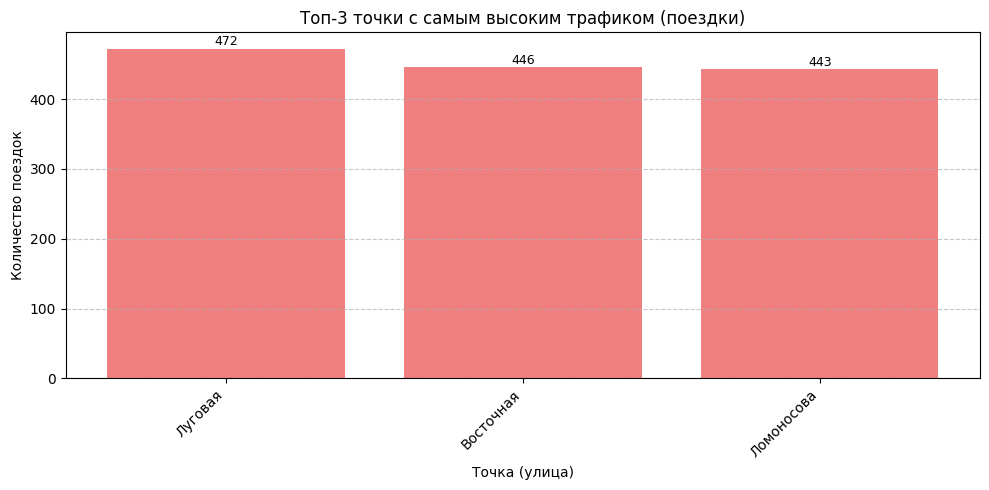

In [32]:
import matplotlib.pyplot as plt

# Отбираем топ-3 точки с наибольшим трафиком
# В данном случае это количество поездок (вы можете изменить столбец, если необходимо)
top_3_traffic = df.groupby('Start Location').size().nlargest(3)  # Группируем по точкам и находим топ-3

# Строим график
plt.figure(figsize=(10, 5))
bars = plt.bar(top_3_traffic.index, top_3_traffic.values, color='lightcoral')

# Подписи на столбиках
for bar in bars:
    height = bar.get_height()  # Получаем высоту столбика (это количество поездок для конкретной локации)
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{int(height)}',
             ha='center', va='bottom', fontsize=9)  # Размещаем текст в центре столбика

# Оформление
plt.title('Топ-3 точки с самым высоким трафиком (поездки)')
plt.xlabel('Точка (улица)')
plt.ylabel('Количество поездок')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Отображение графика
plt.show()


**Стоит ли закрывать некоторые точки?**

In [ ]:
from tqdm import tqdm
merged_df['DateOnly'] = merged_df['Datetime'].dt.date

# Теперь можно сгруппировать по дате
gbd = merged_df.groupby('DateOnly')
list_data = []
for date, group in gbd:
    list_data.append([date, group])

weekdays = {}

# tqdm добавляет прогресс-бар к итерации
for i in tqdm(list_data, desc="Обработка данных по дням недели"):
    f = dict(tuple(i[1].groupby('weekday')))
    ind = list(set(f.keys()))
    for k in ind:
        h = f[k]
        h = h[h['Start Season'] == 'Весна']
        if isinstance(weekdays.get(k, 0), int):
            weekdays[k] = h
        else:
            weekdays[k] = pd.concat([weekdays[k], h])

average_samokat_to_weekdays = []
for i in weekdays.keys():
    da = [i]
    datafr = weekdays[i]
    first = datafr['Start Location'].value_counts().to_frame()
    second = datafr['End Location'].value_counts().to_frame()
    third = datafr.groupby('Start Location')['Trip Cost'].agg('sum').to_frame()
    second.columns = ['leave']
    first.columns = ['inter']
    second.index.name = 'Start Location'
    fin = third.merge(first.merge(second, on='Start Location'), on='Start Location')
    fin['turn_per_day'] = fin['inter'] + fin['leave']
    da.append(fin.sort_values(by='turn_per_day', ascending=False))
    average_samokat_to_weekdays.append(da)

dat = average_samokat_to_weekdays[0][1]
for i in average_samokat_to_weekdays[1:]:
    dat += i[1]

Обработка данных по дням недели: 100%|███████████████████████████████████████████████| 102/102 [00:02<00:00, 47.62it/s]


In [ ]:
for i in un_popular:
    print(i)
    n = arrival_summary_by_end_location[i]
    n['district'] = n['Start Location'].apply(lambda x: reversed_dict[x])
    print(n.head(10))

**Вывод**: не стоит закрывать не одну точку, так как каждая делает свой достаточный вклад в общую сумму выручки.

**Самые популярные направления перемещения**

In [ ]:
# Считаем количество поездок для каждой пары (маршрута)
route_counts = merged_df.groupby(['Start Location', 'End Location']).size().reset_index(name='trips')

# Сортируем по убыванию количества
most_popular_route = route_counts.sort_values(by='trips', ascending=False)

# Выводим результат
start = most_popular_route['Start Location']
end = most_popular_route['End Location']
count = most_popular_route['trips']

most_popular_route.head(10)

**Есть ли необходимость перераспределять самокаты в конце дня?**

In [ ]:
departures = merged_df.groupby('Start Location').size().reset_index(name='departures')
arrivals = merged_df.groupby('End Location').size().reset_index(name='arrivals')

# Объединяем данные
balance = pd.merge(arrivals, departures,
                   left_on='End Location', right_on='Start Location',
                   how='outer')

# Заполняем пропуски нулями (если в локации были только приезды или только уезды)
balance['End Location'] = balance['End Location'].combine_first(balance['Start Location'])
balance = balance.drop(columns=['Start Location'])
balance = balance.rename(columns={'End Location': 'Location'})
balance['arrivals'] = balance['arrivals'].fillna(0)
balance['departures'] = balance['departures'].fillna(0)

# Считаем чистый приток
balance['net_flow'] = balance['arrivals'] - balance['departures']

# Сортировка по притоку
balance = balance.sort_values(by='net_flow', ascending=False)

# Визуализация
plt.figure(figsize=(16, 6))
sns.barplot(data=balance, x='Location', y='net_flow', palette='coolwarm')
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45)
plt.title('Чистый приток самокатов по локациям за день (приехало - уехало)')
plt.ylabel('Чистый приток')
plt.xlabel('Локация')
plt.tight_layout()
plt.show()


# 2.2. Изучить накопительное поведение разницы в трафике в каждой точке

Группировка данных по каждой точке, считаем отток и приток по каждому времени.

In [33]:
import pandas as pd

# Преобразуем данные в нужный формат
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])
df['Date'] = df['Start Date'].dt.date  # Извлекаем только дату

# Отток и приток по точкам (по каждой локации)
outflow = df.groupby(['Date', 'Start Location']).size().reset_index(name='outflow')
inflow = df.groupby(['Date', 'End Location']).size().reset_index(name='inflow')

# Переименуем для объединения данных
outflow.rename(columns={'Start Location': 'Location'}, inplace=True)
inflow.rename(columns={'End Location': 'Location'}, inplace=True)

# Объединяем отток и приток
net_flow = pd.merge(inflow, outflow, on=['Date', 'Location'], how='outer').fillna(0)

# Рассчитываем разницу в трафике
net_flow['net_change'] = net_flow['inflow'] - net_flow['outflow']

# Накопительная сумма для каждой точки по дням
net_flow.sort_values(['Location', 'Date'], inplace=True)
net_flow['cumsum'] = net_flow.groupby(['Location'])['net_change'].cumsum()

# Просмотр результатов
print(net_flow.head())


            Date   Location  inflow  outflow  net_change  cumsum
0     2023-04-22  Береговая     4.0      3.0         1.0     1.0
347   2023-04-23  Береговая     8.0      4.0         4.0     5.0
688   2023-04-24  Береговая     4.0      4.0         0.0     5.0
993   2023-04-25  Береговая     0.0      1.0        -1.0     4.0
1295  2023-04-26  Береговая     3.0      4.0        -1.0     3.0


**Построение графика накопительной разницы по точкам**

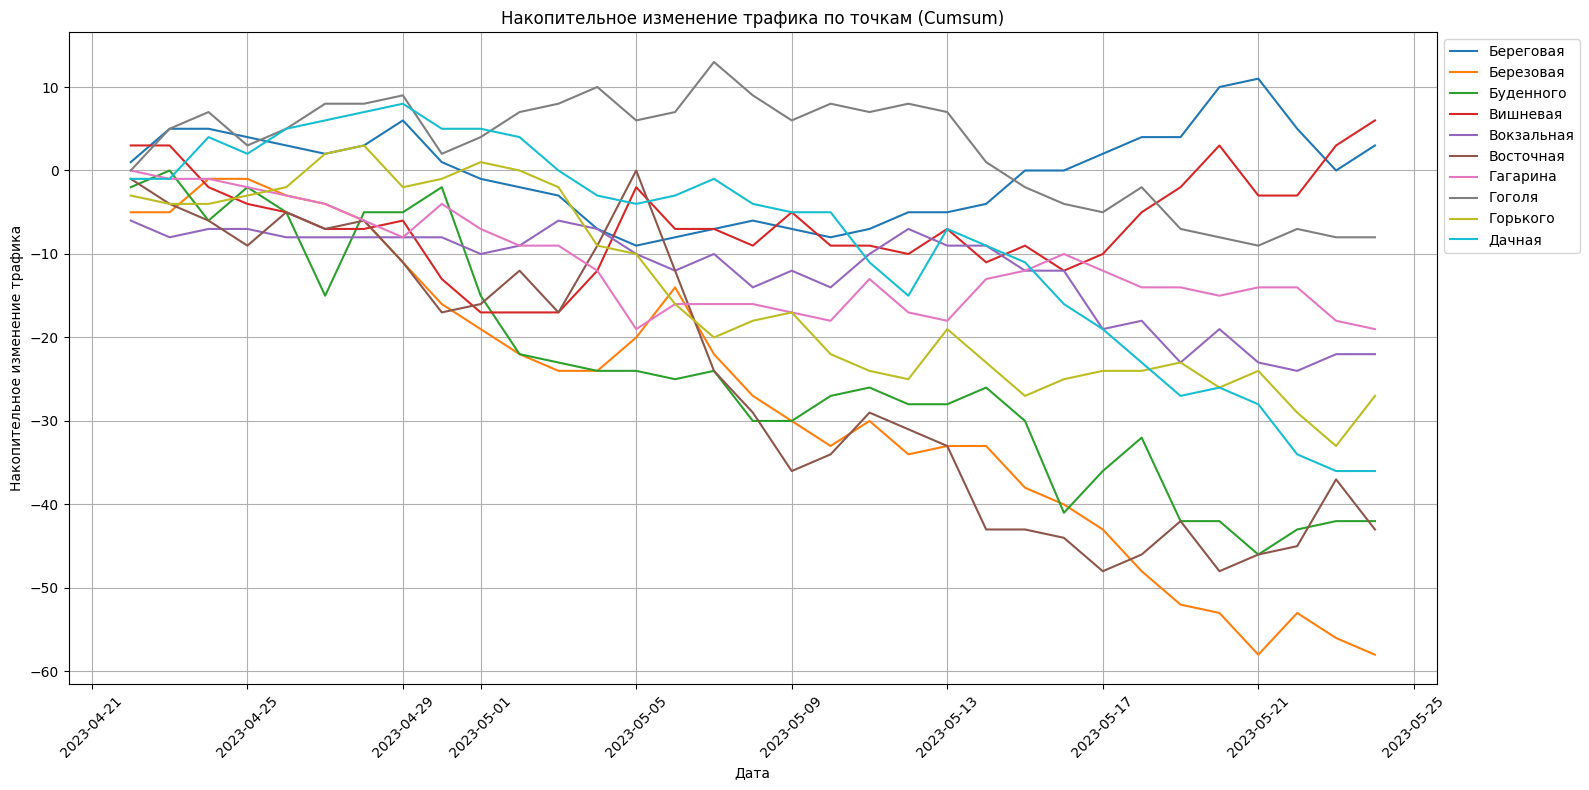

In [34]:
import matplotlib.pyplot as plt

# Группируем по точке и строим графики для каждой точки
locations = net_flow['Location'].unique()

plt.figure(figsize=(16, 8))

for i, loc in enumerate(locations[:10]):  # Ограничим вывод 10 точками для наглядности
    temp = net_flow[net_flow['Location'] == loc]
    plt.plot(temp['Date'], temp['cumsum'], label=loc)

plt.title('Накопительное изменение трафика по точкам (Cumsum)')
plt.xlabel('Дата')
plt.ylabel('Накопительное изменение трафика')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Задача 2: Определить необходимое количество самокатов в каждой точке и районе для удовлетворения спроса в полном объеме**

In [35]:
# Максимальное количество самокатов по каждой точке
required_scooters = net_flow.groupby('Location')['cumsum'].max().reset_index()
required_scooters.rename(columns={'cumsum': 'Required Scooters'}, inplace=True)

# Просмотр результатов
print(required_scooters.head())


     Location  Required Scooters
0   Береговая               11.0
1   Березовая               -1.0
2   Буденного                0.0
3    Вишневая                6.0
4  Вокзальная               -6.0


**Определение необходимого количества самокатов по районам**

In [36]:
# Добавляем информацию о районах
location_district_map = df[['Start Location', 'Start District']].drop_duplicates()
required_scooters = required_scooters.merge(location_district_map, left_on='Location', right_on='Start Location', how='left')

# Рассчитываем необходимое количество самокатов по районам
district_scooters = required_scooters.groupby('Start District')['Required Scooters'].sum().reset_index()

# Просмотр результатов
print(district_scooters.head())


    Start District  Required Scooters
0         Заречный              370.0
1        Ленинский              599.0
2      Октябрьский              540.0
3  Северо-Западный              539.0
4      Центральный             1256.0


**Построение графиков для самокатов по точкам и районам.**




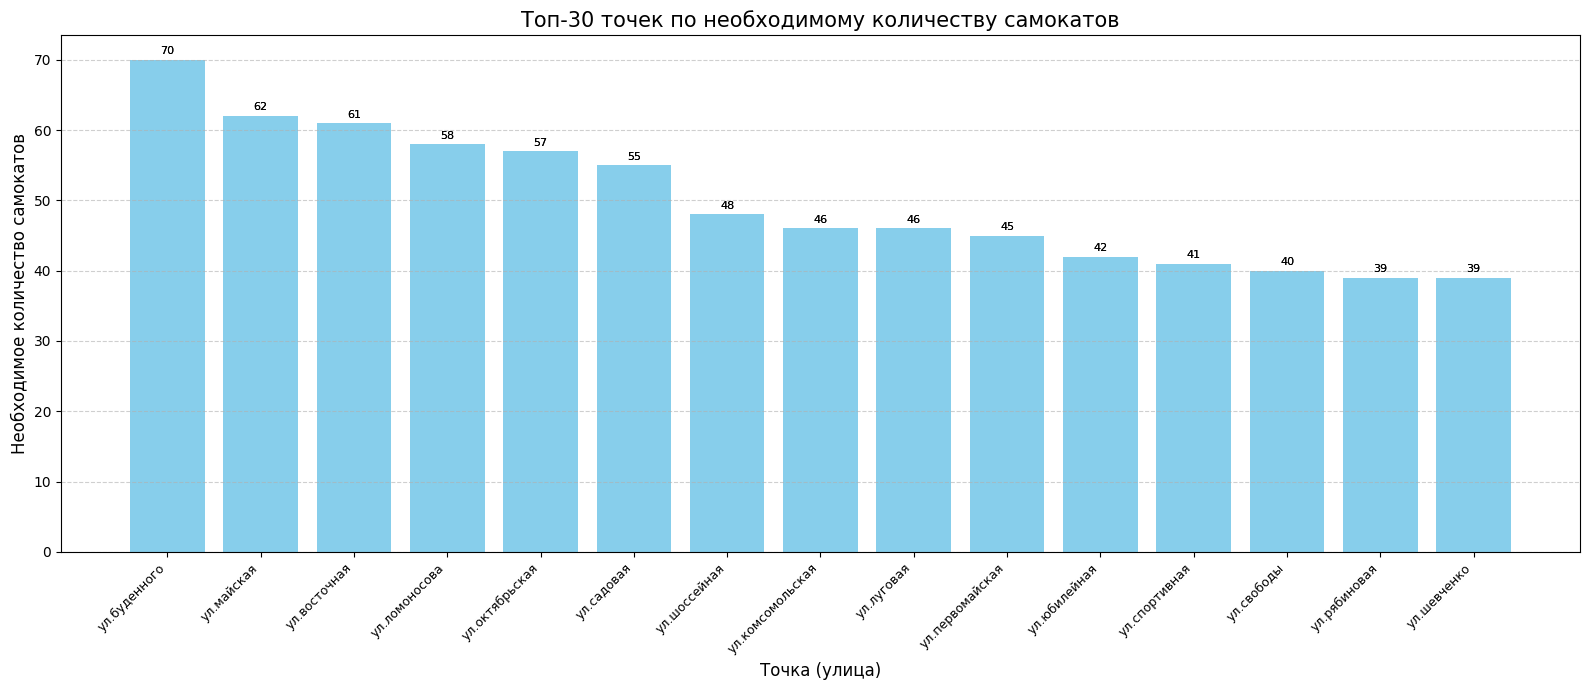

In [43]:
import matplotlib.pyplot as plt

# Отбираем топ-30 точек с наибольшим спросом
top_n = 30
top_scooters = required_scooters.sort_values('Required Scooters', ascending=False).head(top_n)

# Создаём график
plt.figure(figsize=(16, 7))
bars = plt.bar(top_scooters['Location'], top_scooters['Required Scooters'], color='skyblue')

# Добавляем подписи на столбиках
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{int(height)}',
             ha='center', va='bottom', fontsize=8)

# Добавляем пояснение
plt.text(0, top_scooters['Required Scooters'].max() + 3,
         f'',
         fontsize=11, ha='left', va='bottom', color='green')

# Оформление графика
plt.title(f'Топ-{top_n} точек по необходимому количеству самокатов', fontsize=15)
plt.xlabel('Точка (улица)', fontsize=12)
plt.ylabel('Необходимое количество самокатов', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


**По районам -график показывает, сколько самокатов требуется для покрытия ежедневного спроса в различных районах города. Высокие столбцы на графике указывают на районы с более интенсивным спросом на самокаты. В нашем случае - центральный**

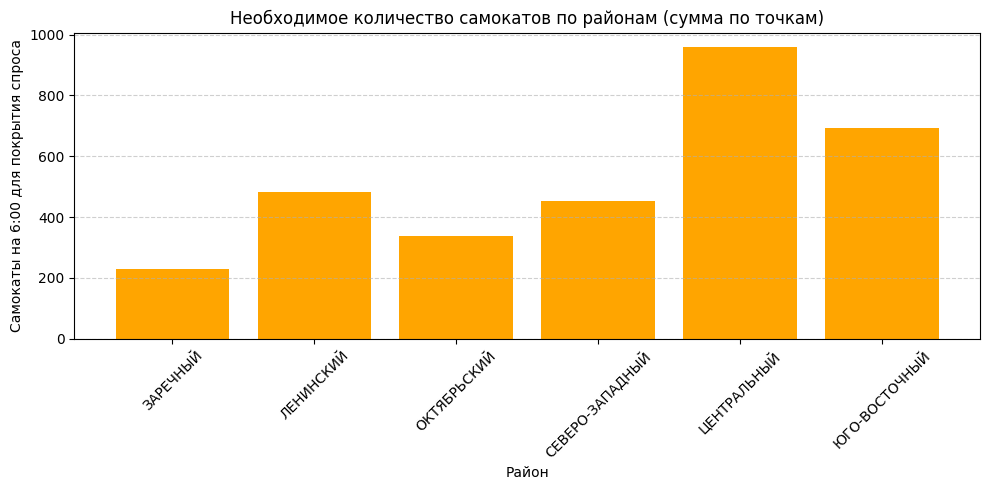

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Подготовка
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])
df['Date'] = df['Start Date'].dt.date
df['Hour'] = df['Start Date'].dt.hour

# 2. Отток и приток по точкам ПОЧАСОВО
out_hour = df.groupby(['Date', 'Hour', 'Start Location']).size().reset_index(name='outflow')
in_hour = df.groupby(['Date', 'Hour', 'End Location']).size().reset_index(name='inflow')

out_hour.rename(columns={'Start Location': 'Location'}, inplace=True)
in_hour.rename(columns={'End Location': 'Location'}, inplace=True)

# 3. Объединение
net_hour = pd.merge(in_hour, out_hour, on=['Date', 'Hour', 'Location'], how='outer').fillna(0)
net_hour['net_change'] = net_hour['inflow'] - net_hour['outflow']

# 4. Накопительный net_change в пределах каждого дня
net_hour.sort_values(['Location', 'Date', 'Hour'], inplace=True)
net_hour['cumsum'] = net_hour.groupby(['Location', 'Date'])['net_change'].cumsum()

# 5. Определяем максимум cumsum в течение каждого дня
daily_max = net_hour.groupby(['Location', 'Date'])['cumsum'].max().reset_index()

# 6. Финальное нужное количество самокатов в точке — максимум по дням
required_scooters = daily_max.groupby('Location')['cumsum'].max().reset_index()
required_scooters.rename(columns={'cumsum': 'Required Scooters'}, inplace=True)

# 7. Привязка районов
location_district_map = df[['Start Location', 'Start District']].drop_duplicates()
required_scooters = required_scooters.merge(location_district_map, left_on='Location', right_on='Start Location', how='left')

# 8. Расчёт по районам (удаляем дубли и приводим к верхнему регистру)
required_scooters['Start District'] = required_scooters['Start District'].str.upper()  # Приводим к верхнему регистру
district_scooters = required_scooters.groupby('Start District')['Required Scooters'].sum().reset_index()

# Убираем повторяющиеся районы
district_scooters = district_scooters.drop_duplicates(subset='Start District')

# -----------------------------
# 📊 ГРАФИК: По районам
# -----------------------------
plt.figure(figsize=(10, 5))
bars = plt.bar(district_scooters['Start District'], district_scooters['Required Scooters'], color='orange')

plt.title('Необходимое количество самокатов по районам (сумма по точкам)')
plt.xlabel('Район')
plt.ylabel('Самокаты на 6:00 для покрытия спроса')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# 3.Исследовать корреляцию между параметрами погодных условий

# Гипотезы - 6 шт

Обосновать для более сильных корреляций - имеет ли это смысл